In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from log_mcx_x_cx_ccx import mcx_log_gate, access_mcx_log_depth, access_mcx_size
from exact_one_x_cx_ccx import exact_one_gate, access_exact_one_depth, access_exact_one_size
from spue_circuit import build_prepare_select_prepare_dag

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.linewidth": 1.8,        
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 16,
    "ytick.labelsize": 14,
})

***Depth and Size scaling of MCX***

In [60]:
log_n_min=1
log_n_max=5
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing MCX with ncontrol = {n}")
    t0 = time.time()

    gate = mcx_log_gate(ncontrol=n, trace_depth_and_size=True)
    d = access_mcx_log_depth(n)

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing MCX with ncontrol = 10
  depth = 17 (took 0.00s)

Processing MCX with ncontrol = 15
  depth = 28 (took 0.00s)

Processing MCX with ncontrol = 22
  depth = 35 (took 0.00s)

Processing MCX with ncontrol = 32
  depth = 35 (took 0.00s)

Processing MCX with ncontrol = 46
  depth = 44 (took 0.00s)

Processing MCX with ncontrol = 68
  depth = 46 (took 0.00s)

Processing MCX with ncontrol = 100
  depth = 53 (took 0.00s)

Processing MCX with ncontrol = 147
  depth = 60 (took 0.00s)

Processing MCX with ncontrol = 215
  depth = 64 (took 0.00s)

Processing MCX with ncontrol = 316
  depth = 71 (took 0.00s)

Processing MCX with ncontrol = 464
  depth = 71 (took 0.00s)

Processing MCX with ncontrol = 681
  depth = 80 (took 0.00s)

Processing MCX with ncontrol = 1000
  depth = 82 (took 0.00s)

Processing MCX with ncontrol = 1468
  depth = 89 (took 0.00s)

Processing MCX with ncontrol = 2154
  depth = 96 (took 0.00s)

Processing MCX with ncontrol = 3162
  depth = 100 (took 0.00s)

Processi

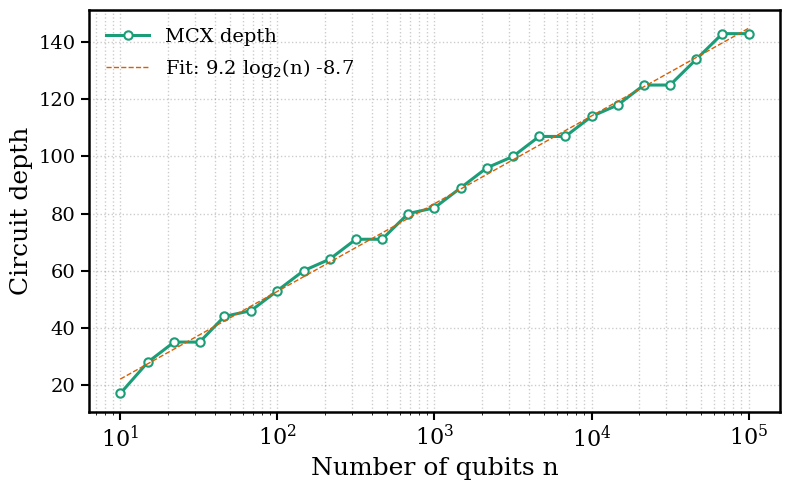

Fit parameters (depth ≈ alpha*log2(n) + beta):
alpha = 9.245228
beta  = -8.678079


In [61]:
log2n = np.log2(ns)
A = np.vstack([log2n, np.ones_like(log2n)]).T
alpha, beta = np.linalg.lstsq(A, depths, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, depths,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="MCX depth"
)

depth_fit = alpha * np.log2(ns) + beta
ax.plot(
    ns, depth_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} log$_2$(n) {beta:+.1f}"
)

ax.set_xscale("log")

ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit depth")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (depth ≈ alpha*log2(n) + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

In [62]:
n_min=1
n_max=10**5
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing MCX with ncontrol = {n}")
    t0 = time.time()

    gate = mcx_log_gate(ncontrol=n, trace_depth_and_size=True)
    d = access_mcx_size(n)

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(d)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)


Processing MCX with ncontrol = 1
  size = 1 (took 0.00s)

Processing MCX with ncontrol = 4168
  size = 16702 (took 0.00s)

Processing MCX with ncontrol = 8334
  size = 33370 (took 0.00s)

Processing MCX with ncontrol = 12501
  size = 50038 (took 0.00s)

Processing MCX with ncontrol = 16668
  size = 66710 (took 0.00s)

Processing MCX with ncontrol = 20834
  size = 83374 (took 0.00s)

Processing MCX with ncontrol = 25001
  size = 100042 (took 0.00s)

Processing MCX with ncontrol = 29167
  size = 116706 (took 0.00s)

Processing MCX with ncontrol = 33334
  size = 133378 (took 0.00s)

Processing MCX with ncontrol = 37501
  size = 150046 (took 0.00s)

Processing MCX with ncontrol = 41667
  size = 166710 (took 0.00s)

Processing MCX with ncontrol = 45834
  size = 183378 (took 0.00s)

Processing MCX with ncontrol = 50000
  size = 200042 (took 0.00s)

Processing MCX with ncontrol = 54167
  size = 216710 (took 0.00s)

Processing MCX with ncontrol = 58334
  size = 233378 (took 0.00s)

Processing

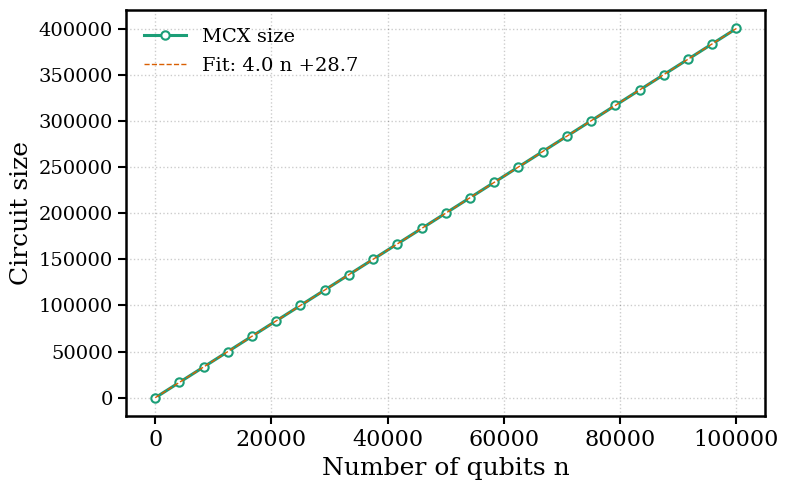

Fit parameters (size ≈ alpha*n + beta):
alpha = 4.000224
beta  = 28.655140


In [63]:
A = np.vstack([ns, np.ones_like(ns)]).T
alpha, beta = np.linalg.lstsq(A, sizes, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, sizes,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="MCX size"
)

size_fit = alpha * ns + beta
ax.plot(
    ns, size_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} n {beta:+.1f}"
)


ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit size")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (size ≈ alpha*n + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

***Depth and Size scaling of Exact One***

In [64]:
log_n_min=1
log_n_max=5
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing Exact One with n = {n}")
    t0 = time.time()

    gate = exact_one_gate(n, trace_depth_and_size=True)
    d = access_exact_one_depth(n)

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing Exact One with n = 10
  depth = 130 (took 0.00s)

Processing Exact One with n = 15
  depth = 182 (took 0.00s)

Processing Exact One with n = 22
  depth = 244 (took 0.00s)

Processing Exact One with n = 32
  depth = 314 (took 0.00s)

Processing Exact One with n = 46
  depth = 314 (took 0.00s)

Processing Exact One with n = 68
  depth = 392 (took 0.00s)

Processing Exact One with n = 100
  depth = 428 (took 0.00s)

Processing Exact One with n = 147
  depth = 470 (took 0.00s)

Processing Exact One with n = 215
  depth = 536 (took 0.00s)

Processing Exact One with n = 316
  depth = 560 (took 0.00s)

Processing Exact One with n = 464
  depth = 626 (took 0.00s)

Processing Exact One with n = 681
  depth = 626 (took 0.00s)

Processing Exact One with n = 1000
  depth = 704 (took 0.00s)

Processing Exact One with n = 1468
  depth = 716 (took 0.00s)

Processing Exact One with n = 2154
  depth = 782 (took 0.00s)

Processing Exact One with n = 3162
  depth = 848 (took 0.00s)

Processin

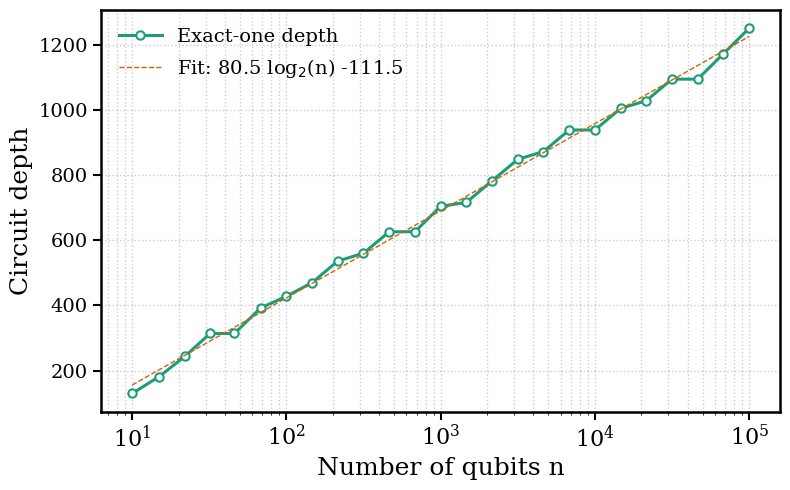

Fit parameters (depth ≈ alpha*log2(n) + beta):
alpha = 80.457878
beta  = -111.538417


In [65]:
log2n = np.log2(ns)
A = np.vstack([log2n, np.ones_like(log2n)]).T
alpha, beta = np.linalg.lstsq(A, depths, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, depths,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="Exact-one depth"
)

depth_fit = alpha * np.log2(ns) + beta
ax.plot(
    ns, depth_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} log$_2$(n) {beta:+.1f}"
)

ax.set_xscale("log")

ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit depth")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (depth ≈ alpha*log2(n) + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

In [66]:
n_min=1
n_max=10**4
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing Exact One with n = {n}")
    t0 = time.time()

    gate = exact_one_gate(n, trace_depth_and_size=True)
    d = access_exact_one_size(n)

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(d)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)


Processing Exact One with n = 1
  size = 1 (took 0.00s)

Processing Exact One with n = 418
  size = 13961 (took 0.00s)

Processing Exact One with n = 834
  size = 27857 (took 0.00s)

Processing Exact One with n = 1251
  size = 41749 (took 0.00s)

Processing Exact One with n = 1668
  size = 55681 (took 0.00s)

Processing Exact One with n = 2084
  size = 69543 (took 0.00s)

Processing Exact One with n = 2501
  size = 83445 (took 0.00s)

Processing Exact One with n = 2917
  size = 97311 (took 0.00s)

Processing Exact One with n = 3334
  size = 111233 (took 0.00s)

Processing Exact One with n = 3751
  size = 125135 (took 0.00s)

Processing Exact One with n = 4167
  size = 138997 (took 0.00s)

Processing Exact One with n = 4584
  size = 152905 (took 0.00s)

Processing Exact One with n = 5000
  size = 166767 (took 0.00s)

Processing Exact One with n = 5417
  size = 180669 (took 0.00s)

Processing Exact One with n = 5834
  size = 194567 (took 0.00s)

Processing Exact One with n = 6250
  size

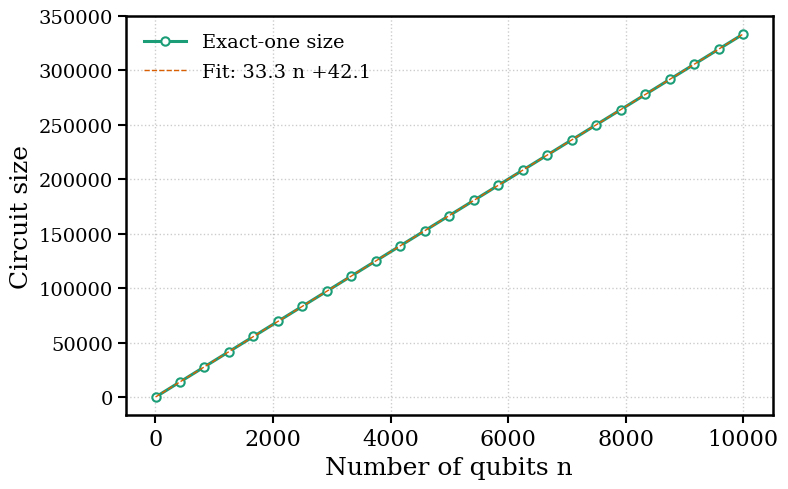

Fit parameters (size ≈ alpha*n + beta):
alpha = 33.343906
beta  = 42.053361


In [67]:
A = np.vstack([ns, np.ones_like(ns)]).T
alpha, beta = np.linalg.lstsq(A, sizes, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, sizes,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="Exact-one size"
)

size_fit = alpha * ns + beta
ax.plot(
    ns, size_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} n {beta:+.1f}"
)


ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit size")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (size ≈ alpha*n + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

***Depth and Size Scaling of SPUE***

In [68]:
log_n_min=1
log_n_max=4
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing SPUE with n = {n}")
    t0 = time.time()

    qc = build_prepare_select_prepare_dag(n)
    qc = transpile(qc, basis_gates=['x','cx','ccx','u'])
    d = qc.depth()

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing SPUE with n = 10
  depth = 267 (took 0.05s)

Processing SPUE with n = 13
  depth = 315 (took 0.02s)

Processing SPUE with n = 18
  depth = 457 (took 0.02s)

Processing SPUE with n = 24
  depth = 505 (took 0.03s)

Processing SPUE with n = 32
  depth = 639 (took 0.04s)

Processing SPUE with n = 42
  depth = 639 (took 0.04s)

Processing SPUE with n = 56
  depth = 771 (took 0.06s)

Processing SPUE with n = 75
  depth = 797 (took 0.07s)

Processing SPUE with n = 100
  depth = 869 (took 0.08s)

Processing SPUE with n = 133
  depth = 955 (took 0.12s)

Processing SPUE with n = 178
  depth = 955 (took 0.14s)

Processing SPUE with n = 237
  depth = 1087 (took 0.18s)

Processing SPUE with n = 316
  depth = 1137 (took 0.25s)

Processing SPUE with n = 422
  depth = 1269 (took 0.37s)

Processing SPUE with n = 562
  depth = 1271 (took 0.46s)

Processing SPUE with n = 750
  depth = 1271 (took 0.59s)

Processing SPUE with n = 1000
  depth = 1427 (took 0.86s)

Processing SPUE with n = 1334
 

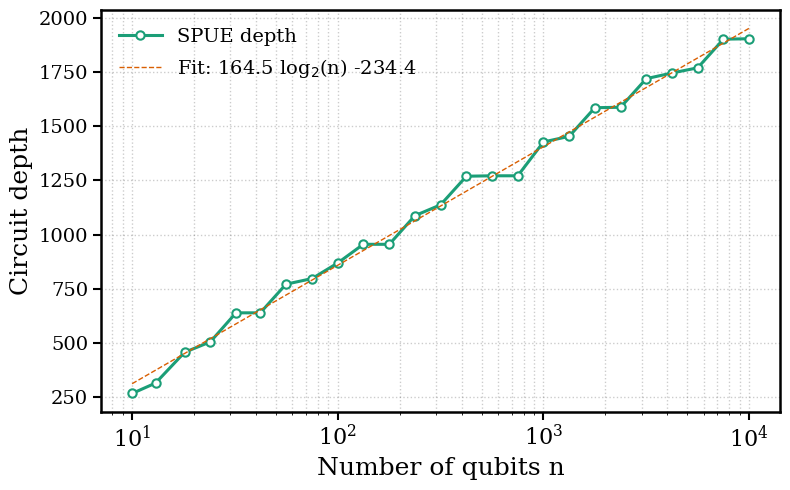

Fit parameters (depth ≈ alpha*log2(n) + beta):
alpha = 164.491871
beta  = -234.352111


In [69]:
log2n = np.log2(ns)
A = np.vstack([log2n, np.ones_like(log2n)]).T
alpha, beta = np.linalg.lstsq(A, depths, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, depths,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="SPUE depth"
)

depth_fit = alpha * np.log2(ns) + beta
ax.plot(
    ns, depth_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} log$_2$(n) {beta:+.1f}"
)

ax.set_xscale("log")

ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit depth")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (depth ≈ alpha*log2(n) + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

In [70]:
n_min=2
n_max=10**4
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing SPUE with n = {n}")
    t0 = time.time()

    qc = build_prepare_select_prepare_dag(n)
    qc = transpile(qc, basis_gates=['x','cx','ccx','u'])
    s = qc.size()

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(s)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)





Processing SPUE with n = 2
  size = 1903 (took 0.01s)

Processing SPUE with n = 419
  size = 1903 (took 0.26s)

Processing SPUE with n = 835
  size = 1903 (took 0.58s)

Processing SPUE with n = 1252
  size = 1903 (took 0.92s)

Processing SPUE with n = 1668
  size = 1903 (took 1.23s)

Processing SPUE with n = 2085
  size = 1903 (took 2.03s)

Processing SPUE with n = 2502
  size = 1903 (took 1.86s)

Processing SPUE with n = 2918
  size = 1903 (took 2.31s)

Processing SPUE with n = 3335
  size = 1903 (took 3.17s)

Processing SPUE with n = 3751
  size = 1903 (took 3.33s)

Processing SPUE with n = 4168
  size = 1903 (took 3.46s)

Processing SPUE with n = 4584
  size = 1903 (took 3.94s)

Processing SPUE with n = 5001
  size = 1903 (took 4.71s)

Processing SPUE with n = 5418
  size = 1903 (took 4.72s)

Processing SPUE with n = 5834
  size = 1903 (took 5.50s)

Processing SPUE with n = 6251
  size = 1903 (took 5.95s)

Processing SPUE with n = 6667
  size = 1903 (took 6.25s)

Processing SPUE wi

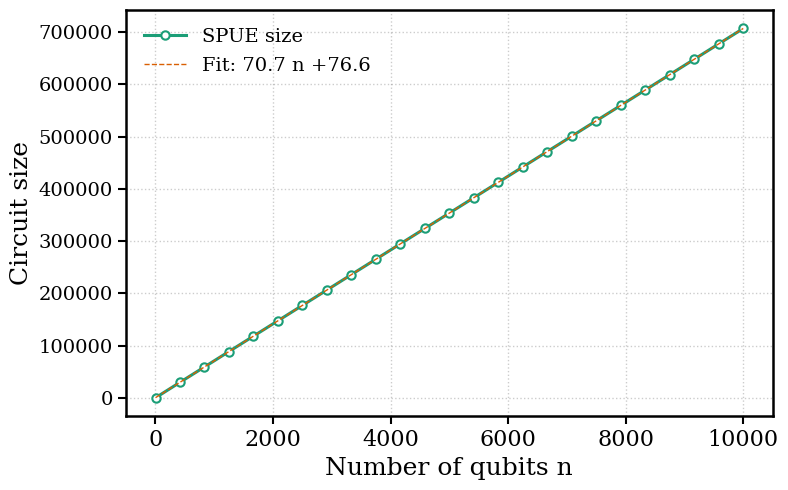

Fit parameters (size ≈ alpha*n + beta):
alpha = 70.688983
beta  = 76.635826


In [71]:
A = np.vstack([ns, np.ones_like(ns)]).T
alpha, beta = np.linalg.lstsq(A, sizes, rcond=None)[0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, sizes,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",        
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="SPUE size"
)

size_fit = alpha * ns + beta
ax.plot(
    ns, size_fit,
    linestyle="--",
    linewidth=1,
    color="#d95f02",
    label=rf"Fit: {alpha:.1f} n {beta:+.1f}"
)


ax.set_xlabel(r"Number of qubits n")
ax.set_ylabel(r"Circuit size")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.2)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=14, handlelength=2.2, labelspacing=0.6)

plt.tight_layout()
plt.show()

print(f"Fit parameters (size ≈ alpha*n + beta):")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")